In [ ]:
!pip install torch pandas scikit-learn gensim transformers nltk -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.8 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import random
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from transformers import MarianMTModel, MarianTokenizer

In [ ]:
import re

## Tatoeba
Я решила повторить эксперимент на другом языке. Корпус -- [параллельные предложения](https://tatoeba.org/ru/downloads) английский <--> финский. Создадим обучающий датасет.

SARAL работает по такому пайплайну:
```
Foreign Sentence S: [f1, f2, f3, f4, f5]
                ↓ MT
English Translations: T1, T2, T3 (multiple translations)
                ↓
Label:
IF any T contains query term q:
  S is relevant (label=1)
ELSE:
  S is irrelevant (label=0)
```
То есть главная идея в том, что у нас нет большого параллельного корпуса целиковых предложений. Мы создаем синтетический датасет с помощью довольно примитивного MT, используя **только документы на иностранном языке**.

Конечно, можно было бы сразу использовать Tatoeba -- но мы следуем пайплайну из статьи.

### 1. Предложения на финском

In [ ]:
data = pd.read_csv(
    "/content/Пары предложений на английский-финский - 2026-03-12.tsv",
    sep="\t",
    header=None,
    names=["eng_id","eng","fin_id","fin"]
)
print(data.head())

   eng_id                     eng   fin_id                            fin
0    1276    Let's try something.   335578          Kokeillaanpa jotakin!
1    1276    Let's try something.  1030741             Koitetaanpas tätä!
2    1276    Let's try something.  2740008              Yritetään jotain.
3    1277  I have to go to sleep.   335579  Minun täytyy mennä nukkumaan.
4    1282      Muiriel is 20 now.  1031670  Muiriel on nyt kaksikymmentä.


In [ ]:
# выбираю не слишком короткие ТОЛЬКО ФИНСКИЕ предложения
data = data[
    (data.fin.str.split().str.len() >= 5)
]
# возьмем только 200 предложений, при этом будем брать каждое десятое для разнообразия.
# иначе наш MT будет работать очень долго
finnish_sentences = data["fin"].dropna().tolist()[::20][:500]
print("Finnish sentences:", len(finnish_sentences))

Finnish sentences: 500


### 2. MT модель
Обучена командой университета Хельсинки на корпусе параллельных текстов OPUS. Фреймворк Marian NMT.

In [ ]:
model_name = "Helsinki-NLP/opus-mt-fi-en"

mt_tokenizer = MarianTokenizer.from_pretrained(model_name)
mt_model = MarianMTModel.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
# функция для перевода
def translate_batch(sentences, num_translations=2):
    batch = mt_tokenizer(
        sentences,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    translated = mt_model.generate(
        **batch,
        num_beams=num_translations,
        num_return_sequences=num_translations,   # key change
        early_stopping=True
    )

    # returns a flat list: [s0_t0, s0_t1, ..., s0_tN, s1_t0, ...]
    all_translations = mt_tokenizer.batch_decode(translated, skip_special_tokens=True)

    # reshape into list of lists: [[t0,t1,t2,t3], [t0,t1,t2,t3], ...]
    n = len(sentences)
    return [all_translations[i*num_translations:(i+1)*num_translations] for i in range(n)]

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words("english"))
print(len(STOPWORDS))

198


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import defaultdict

In [ ]:
batch_size = 20
# translate_batch now returns List[List[str]] — one list of translations per sentence
translated_pairs = []
for i in tqdm(range(0, len(finnish_sentences), batch_size)):
    batch = finnish_sentences[i:i+batch_size]
    translations_per_sentence = translate_batch(batch)   # [[t0,t1,t2,t3], ...]
    for fin, translations in zip(batch, translations_per_sentence):
        translated_pairs.append((fin, translations))     # (finnish, [t0,t1,t2,t3])

100%|██████████| 25/25 [01:20<00:00,  3.23s/it]


In [ ]:
all_english_texts = []
for fin, translations in translated_pairs:
    all_english_texts.extend(translations)

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=50,
    ngram_range=(1, 1)
)
vectorizer.fit(all_english_texts)
tfidf_terms = set(vectorizer.get_feature_names_out())

def extract_queries(sentence):
    words = [w.lower() for w in sentence.split() if w.lower() not in STOPWORDS]
    queries = []
    for w in words:
        if w in tfidf_terms:
            queries.append(w)
    return queries

In [ ]:
# In build_dataset: label=1 if query appears in ANY translation
def build_dataset(pairs, negatives=3):
    dataset = []
    finnish_docs = [p[0] for p in pairs]
    for fin, translations in tqdm(pairs):
        # collect all queries from all translations
        all_queries = set()
        for t in translations:
            all_queries.update(extract_queries(t))
        for q in all_queries:
            if not q:
                continue
            # label=1: the Finnish sentence has at least one translation containing q
            dataset.append((q, fin, 1))
            for _ in range(negatives):
                neg_doc = random.choice(finnish_docs)
                dataset.append((q, neg_doc, 0))
    return dataset

Тренировочный датасет размером ~5000 пар.

In [ ]:
dataset = build_dataset(translated_pairs)
print("dataset size:", len(dataset))

100%|██████████| 500/500 [00:00<00:00, 124719.12it/s]

dataset size: 1452


In [ ]:
random.shuffle(dataset)

# разделение на тестовую и обучающую выборки
split = int(0.8 * len(dataset))
train_data = dataset[:split]
test_data = dataset[split:]

Пример данных:

In [ ]:
train_data[31]

('want', 'Käytkö tässä kaupugissa ensimmäistä kertaa?', 0)

Класс датасета

In [ ]:
# vocabularies
from collections import Counter

# Extract English queries and Finnish documents from dataset
english_queries = [item[0] for item in dataset]
finnish_docs = [item[1] for item in dataset]

In [ ]:
# Build vocabulary on BOTH English and Finnish
# This way the model learns the alignment better
def build_vocab_bilingual(eng_texts, fin_texts, min_freq=1):
    counter = Counter()
    for text in eng_texts + fin_texts:
        counter.update(text.split())

    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2

    for word, freq in counter.most_common():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab

# Use same vocab for both:
shared_vocab = build_vocab_bilingual(english_queries, finnish_docs)
eng_vocab = shared_vocab
fin_vocab = shared_vocab

In [ ]:
# Cell: Define encode function and constants
MAX_QUERY = 20  # Maximum query length
MAX_DOC = 100   # Maximum document length

def encode(text, vocab, max_len):
    """
    Encode text into token IDs using the vocabulary.
    Pads or truncates to max_len.
    """
    tokens = text.split()

    # Convert words to token IDs
    token_ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]

    # Truncate if too long
    if len(token_ids) > max_len:
        token_ids = token_ids[:max_len]

    # Pad if too short
    pad_id = vocab["<PAD>"]
    token_ids += [pad_id] * (max_len - len(token_ids))

    return token_ids

In [ ]:
class CLIRDataset(Dataset):

    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        q, d, y = self.data[idx]

        q = torch.tensor(encode(q, eng_vocab, MAX_QUERY))
        d = torch.tensor(encode(d, fin_vocab, MAX_DOC))

        y = torch.tensor(float(y))

        return q, d, y

In [ ]:
train_loader = DataLoader(
    CLIRDataset(train_data),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    CLIRDataset(test_data),
    batch_size=32
)

### CNN-энкодер иностранных предложений
Я вслед за (Boschee et al. 2019) опираюсь на ([Gehring et al. 2017](https://arxiv.org/pdf/1705.03122)).

In [ ]:
class CNNEncoder(nn.Module):
    def __init__(self, vocab_size, dim=128, num_layers=4, max_len=512):
        super().__init__()
        self.word_embedding = nn.Embedding(vocab_size, dim, padding_idx=0)
        self.pos_embedding  = nn.Embedding(max_len, dim)

        # Each conv outputs 2*dim so GLU can split it into dim
        self.convs = nn.ModuleList([
            nn.Conv1d(dim, dim * 2, kernel_size=3, padding=1)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        # x: (batch, seq_len) token ids

        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        out = self.word_embedding(x) + self.pos_embedding(positions)
        # out: (batch, seq_len, dim)

        for conv in self.convs:
            residual = out
            # Conv1d expects (batch, channels, seq_len)
            h = conv(out.transpose(1, 2))          # → (batch, 2*dim, seq_len)
            h = h.transpose(1, 2)                  # → (batch, seq_len, 2*dim)

            # GLU: split into A and B, gate A with sigmoid(B)
            A, B = h.chunk(2, dim=-1)              # each (batch, seq_len, dim)
            out = A * torch.sigmoid(B) + residual  # residual connection

        return out  # (batch, seq_len, dim)

### Энкодер запроса (на английском)

In [ ]:
class QueryEncoder(nn.Module):

    def __init__(self, vocab_size, dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, dim)

    def forward(self, q):
        return self.embedding(q)

### Модель Searcher

#### Attention
(Boschee et al. 2019) только описывает примерную архитектуру, но конкретной реализации не предлагает.
> an attention mechanism for aligning query terms with specific foreign-language terms

Я реализую самую базовую версию.

In [ ]:
class SEARCHER(nn.Module):
    def __init__(self, query_vocab_size, doc_vocab_size, dim=128, num_layers=4, max_len=512):
        super().__init__()

        self.query_encoder = nn.Embedding(query_vocab_size, dim, padding_idx=0)

        self.doc_word_embedding = nn.Embedding(doc_vocab_size, dim, padding_idx=0)
        self.doc_pos_embedding  = nn.Embedding(max_len, dim)
        self.convs = nn.ModuleList([
            nn.Conv1d(dim, dim * 2, kernel_size=3, padding=1)
            for _ in range(num_layers)
        ])

        self.mlp = nn.Sequential(
            nn.Linear(dim, 128),
            nn.Dropout(0.4),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def encode_doc(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        out = self.doc_word_embedding(x) + self.doc_pos_embedding(positions)
        for conv in self.convs:
            residual = out
            h = conv(out.transpose(1, 2)).transpose(1, 2)
            A, B = h.chunk(2, dim=-1)
            out = A * torch.sigmoid(B) + residual
        return out

    def forward(self, query_ids, doc_ids):
        E = self.query_encoder(query_ids)
        F = self.encode_doc(doc_ids)

        scale = F.size(-1) ** 0.5
        A = torch.softmax(torch.bmm(E, F.transpose(1, 2)) / scale, dim=-1)
        D = torch.bmm(A, F)

        pooled = D.mean(dim=1)
        return self.mlp(pooled)

Статья не специфицирует конкретные гиперпараметры.

### Оценка

In [ ]:
# переводим модель в режим тестирования
def evaluate_model(model, loader):

    model.eval()
    scores = []
    labels = []

    with torch.no_grad():
        for q,d,y in loader:
            pred = model(q,d)
            scores.extend(pred.tolist())
            labels.extend(y.tolist())

    return scores, labels

In [ ]:
def compute_aqwv(model, dataloader, beta=10, threshold=0.5, verbose=False):
    model.eval()
    all_scores = []
    all_labels = []
    with torch.no_grad():
        for batch in dataloader:
            query, doc, label = batch
            output = model(query, doc)
            scores = torch.sigmoid(output.squeeze())

            if scores.dim() == 0:
                all_scores.append(scores.item())
            else:
                all_scores.extend(scores.tolist())

            if label.dim() == 0:
                all_labels.append(label.item())
            else:
                all_labels.extend(label.tolist())

    preds = [1 if s > threshold else 0 for s in all_scores]
    tp = sum(p == 1 and l == 1 for p, l in zip(preds, all_labels))
    fp = sum(p == 1 and l == 0 for p, l in zip(preds, all_labels))
    fn = sum(p == 0 and l == 1 for p, l in zip(preds, all_labels))
    tn = sum(p == 0 and l == 0 for p, l in zip(preds, all_labels))

    if verbose:
        print(f"TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")
        print(f"Avg score: {sum(all_scores)/len(all_scores):.4f}")
        print(f"Positive labels: {sum(all_labels)}/{len(all_labels)}")

    if (tp + fn) == 0:
        return 0.0

    return 1 - (fn + beta * fp) / (tp + fn)

### Training loop

In [ ]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

In [ ]:
model = SEARCHER(
    query_vocab_size=len(eng_vocab),
    doc_vocab_size=len(fin_vocab),
    dim=128,
    num_layers=4,
    max_len=512
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

Epoch 1: 100%|██████████| 9/9 [00:00<00:00,  9.13it/s]


Epoch 1, Loss: 0.6366, AQWV: 0.0000


Epoch 2: 100%|██████████| 9/9 [00:00<00:00,  9.18it/s]


Epoch 2, Loss: 0.5653, AQWV: 0.0000


Epoch 3: 100%|██████████| 9/9 [00:00<00:00,  9.22it/s]


...

Epoch 28, Loss: 0.2596, AQWV: -5.5000


Epoch 29: 100%|██████████| 9/9 [00:01<00:00,  8.05it/s]


Epoch 29, Loss: 0.1374, AQWV: -7.4375


Epoch 30: 100%|██████████| 9/9 [00:01<00:00,  6.14it/s]


Epoch 30, Loss: 0.1838, AQWV: -7.8125


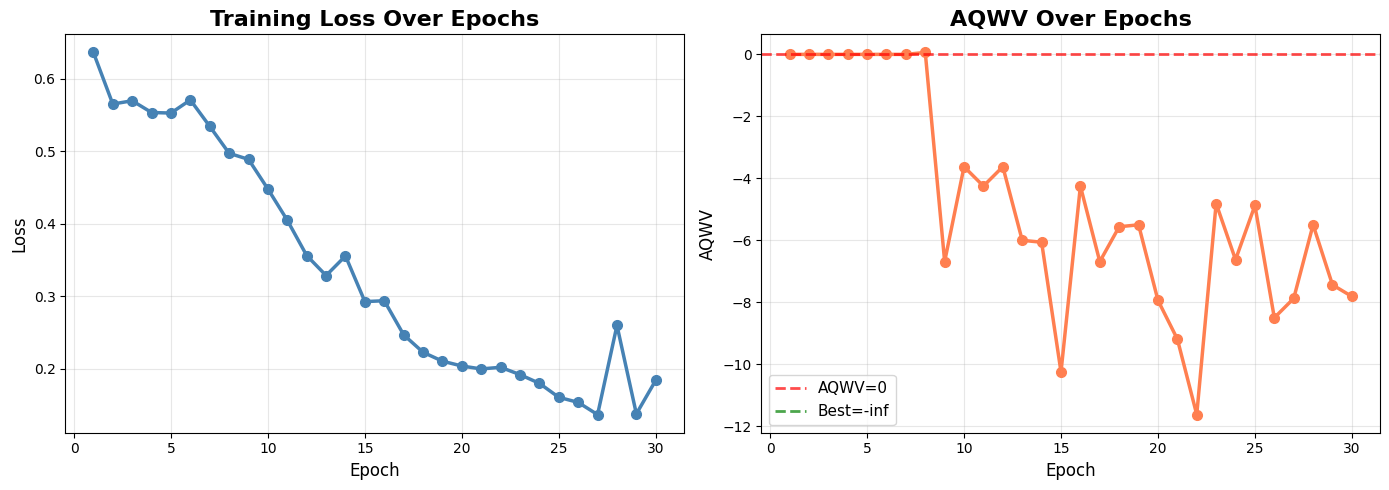


Training Complete!
Best AQWV: -inf
Final Loss: 0.1838


In [ ]:
import matplotlib.pyplot as plt

train_losses = []
aqwv_scores = []
epochs_list = []

best_aqwv = -float('inf')
patience = 5
patience_counter = 0

for epoch in range(30):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        query, doc, label = batch
        optimizer.zero_grad()
        output = model(query, doc)
        loss = criterion(output, label.float().unsqueeze(1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    aqwv = compute_aqwv(model, test_loader, threshold=0.5)

    train_losses.append(avg_loss)
    aqwv_scores.append(aqwv)
    epochs_list.append(epoch + 1)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, AQWV: {aqwv:.4f}")

    # # Early stopping
    # if aqwv > best_aqwv:
    #     best_aqwv = aqwv
    #     patience_counter = 0
    #     torch.save(model.state_dict(), 'best_model.pt')
    # else:
    #     patience_counter += 1
    #     if patience_counter >= patience:
    #         print(f"Early stopping at epoch {epoch+1}, Best AQWV: {best_aqwv:.4f}")
    #         model.load_state_dict(torch.load('best_model.pt'))
    #         break

# Final summary plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_list, train_losses, color='steelblue', marker='o', linewidth=2.5, markersize=7)
ax1.set_title('Training Loss Over Epochs', fontsize=16, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_list, aqwv_scores, color='coral', marker='o', linewidth=2.5, markersize=7)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='AQWV=0')
ax2.axhline(y=best_aqwv, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Best={best_aqwv:.4f}')
ax2.set_title('AQWV Over Epochs', fontsize=16, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('AQWV', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Training Complete!")
print(f"Best AQWV: {best_aqwv:.4f}")
print(f"Final Loss: {train_losses[-1]:.4f}")
print(f"{'='*50}")

Финальная оценка:

In [ ]:
aqwv = compute_aqwv(model, test_loader)
print("AQWV:", aqwv)

AQWV: -7.8125


# Discussion

#### Моё впечатление
Авторы очень смело не приложили к статье никакого кода -- поэтому подробности архитектуры покрыты завесой тайны.

В этом блокноте я реализовала только SEARCH, но не остальной функционал.

#### Какие базовые улучшения я сделала, чтобы AQWV хотя бы не снижался.

1. TF-IDF  для извлечения запросов
2. Shared vocabulary - единый словарь для английского и финского
3. CNN encoder с GLU
4. Hard negatives --> модели стало совсем тяжело
5. Разные пороги классификации (0.2-0.8)
6. Увеличение отрицательных примеров (1:3)
7. Регуляризация, dropout, early stopping

Ничего существенно не помогло. AQWV так и не поднялся выше 0.

В некоторых экспериментах буквально на 1-2 эпохе он становится положительный (~0.14), но потом снова снижается.

Соотношение кривых обучения и AQWV указывает на переобучение.
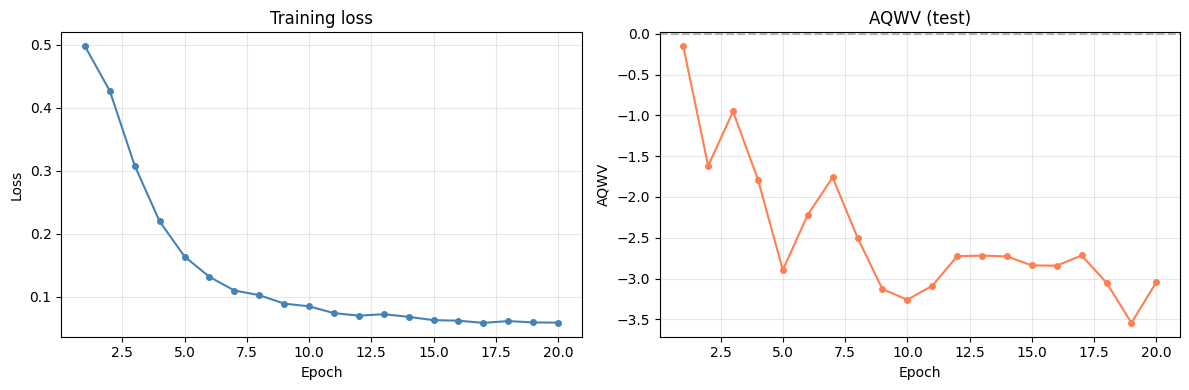

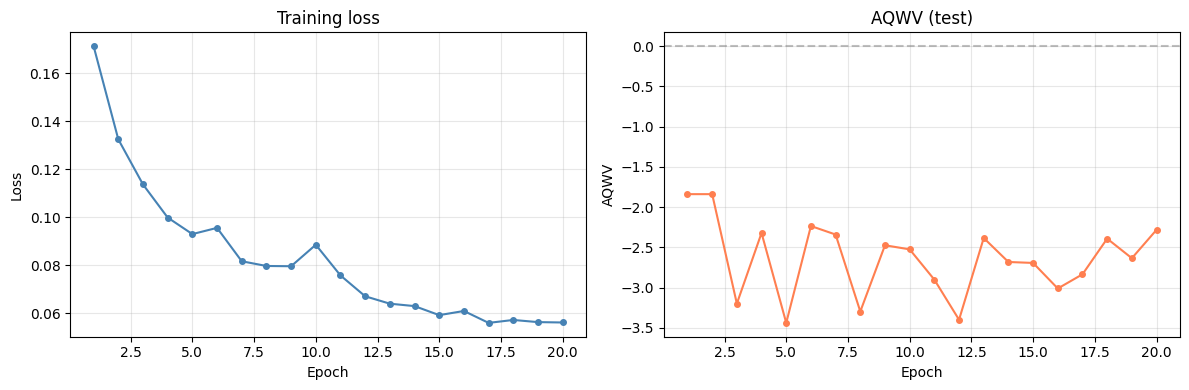

(n=200 исходных предложений)

#### Почему AQWV не поднимается выше 0
* Модель должна матчить **английские** запросы к **финским** документам
* Это требует cross-lingual semantic understanding без явного обучения на параллельных корпусах
* Shared vocabulary недостаточен --- нужны **cross-lingual embeddings** (типа mBERT, XLM)

#### Низкое качество данных
* Запросы -- случайные n-граммы из переводов, часто неграмотные
* Истинные соответствия слабые -- модель не может научиться различать их

Но что ещё мы можем ожидать от синтетически сгенерированного датасета? (А именно такая идея у SARAL)

# Файнтьюнинг с cross-lingual embeddings

В этом разделе я заменяю CNN-энкодер на **`distiluse-base-multilingual-cased-v1`** из библиотеки `sentence-transformers`.

Это наименьшая multilingual sentence-embedding модель (~135M параметров), которая поддерживает финский и английский в одном пространстве. В отличие от полного mBERT (110M только для BERT-base, ~440MB) или XLM-R (270M), distiluse компактнее и быстрее для файнтьюнинга на малых данных.

**Идея**: оба текста (английский запрос и финский документ) кодируются **одной и той же** моделью, что автоматически даёт cross-lingual alignment. Затем обучается только небольшая классификационная голова поверх косинусного сходства.

In [ ]:
!pip install sentence-transformers -q

In [ ]:
from sentence_transformers import SentenceTransformer
import torch
import torch.nn as nn

# Smallest multilingual model that covers Finnish + English
# ~135M params, 512-dim embeddings
SBERT_MODEL_NAME = "distiluse-base-multilingual-cased-v1"
sbert = SentenceTransformer(SBERT_MODEL_NAME)
print("Embedding dim:", sbert.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/556 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

Embedding dim: 512


### Dataset для файнтьюнинга
Тот же синтетический датасет `(query_en, doc_fi, label)`, но теперь тексты токенизируются через SBERT tokenizer.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class CLIRSBERTDataset(Dataset):
    """Dataset that returns raw text pairs -- SBERT tokenizes internally."""
    def __init__(self, data):
        self.data = data  # list of (query_str, doc_str, label)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        q, d, y = self.data[idx]
        return q, d, float(y)


def collate_fn(batch):
    queries, docs, labels = zip(*batch)
    return list(queries), list(docs), torch.tensor(labels, dtype=torch.float32)


ft_train_loader = DataLoader(
    CLIRSBERTDataset(train_data),
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

ft_test_loader = DataLoader(
    CLIRSBERTDataset(test_data),
    batch_size=32,
    collate_fn=collate_fn
)

print(f"Train batches: {len(ft_train_loader)}, Test batches: {len(ft_test_loader)}")

Train batches: 37, Test batches: 10


### Архитектура

```
query (EN)  ──► SBERT ──► q_emb (512-d)
                                        ──► [q_emb, d_emb, |q-d|, q*d] ──► MLP ──► score
doc   (FI)  ──► SBERT ──► d_emb (512-d)
```

SBERT уже выровнял пространства EN и FI. Мы обучаем только MLP-голову (≈1K параметров), опционально также файнтьюним последний слой SBERT.

In [ ]:
class SBERTRelevanceModel(nn.Module):
    """
    Wraps SBERT + a small MLP head.
    Encodes query (EN) and doc (FI) with the same multilingual SBERT,
    then predicts relevance from the combined representation.
    """
    def __init__(self, sbert_model, freeze_sbert=True):
        super().__init__()
        self.sbert = sbert_model
        dim = sbert_model.get_sentence_embedding_dimension()

        # Freeze SBERT by default -- fine-tune only the head
        if freeze_sbert:
            for param in self.sbert.parameters():
                param.requires_grad = False

        # Input: [q, d, |q-d|, q*d]  → 4 * dim
        self.classifier = nn.Sequential(
            nn.Linear(4 * dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def encode(self, texts):
        """Encode a list of strings → (batch, dim) tensor."""
        # SentenceTransformer.encode returns numpy; convert to tensor
        emb = self.sbert.encode(texts, convert_to_tensor=True,
                                show_progress_bar=False)
        return emb  # (batch, dim)

    def forward(self, queries, docs):
        q_emb = self.encode(queries)   # (B, dim)
        d_emb = self.encode(docs)      # (B, dim)

        # Feature engineering: concat, abs diff, element-wise product
        features = torch.cat([q_emb, d_emb,
                               torch.abs(q_emb - d_emb),
                               q_emb * d_emb], dim=-1)  # (B, 4*dim)
        return self.classifier(features)  # (B, 1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

sbert_model = SBERTRelevanceModel(sbert, freeze_sbert=True).to(device)

# Only MLP head parameters are trainable
trainable = sum(p.numel() for p in sbert_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in sbert_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Device: cuda
Trainable params: 524,801 / 135,652,609


In [ ]:
def compute_aqwv_sbert(model, dataloader, beta=10, threshold=0.5, verbose=False):
    model.eval()
    all_scores = []
    all_labels = []
    with torch.no_grad():
        for queries, docs, labels in dataloader:
            output = model(queries, docs).squeeze()
            scores = torch.sigmoid(output)

            if scores.dim() == 0:
                all_scores.append(scores.item())
            else:
                all_scores.extend(scores.tolist())
            all_labels.extend(labels.tolist())

    preds = [1 if s > threshold else 0 for s in all_scores]
    tp = sum(p == 1 and l == 1 for p, l in zip(preds, all_labels))
    fp = sum(p == 1 and l == 0 for p, l in zip(preds, all_labels))
    fn = sum(p == 0 and l == 1 for p, l in zip(preds, all_labels))

    if verbose:
        print(f"TP: {tp}, FP: {fp}, FN: {fn}")
        print(f"Positive labels: {sum(all_labels)}/{len(all_labels)}")

    if (tp + fn) == 0:
        return 0.0
    return 1 - (fn + beta * fp) / (tp + fn)

### Обучение MLP-головы

FT Epoch 1: 100%|██████████| 37/37 [00:01<00:00, 22.07it/s]


Epoch 1, Loss: 0.5675, AQWV: 0.0000


FT Epoch 2: 100%|██████████| 37/37 [00:01<00:00, 22.89it/s]


Epoch 2, Loss: 0.5362, AQWV: 0.0000


FT Epoch 3: 100%|██████████| 37/37 [00:01<00:00, 22.57it/s]


...

Epoch 28, Loss: 0.3462, AQWV: -1.3553


FT Epoch 29: 100%|██████████| 37/37 [00:01<00:00, 20.02it/s]


Epoch 29, Loss: 0.3500, AQWV: -0.8947


FT Epoch 30: 100%|██████████| 37/37 [00:01<00:00, 19.51it/s]


Epoch 30, Loss: 0.3441, AQWV: -1.2632


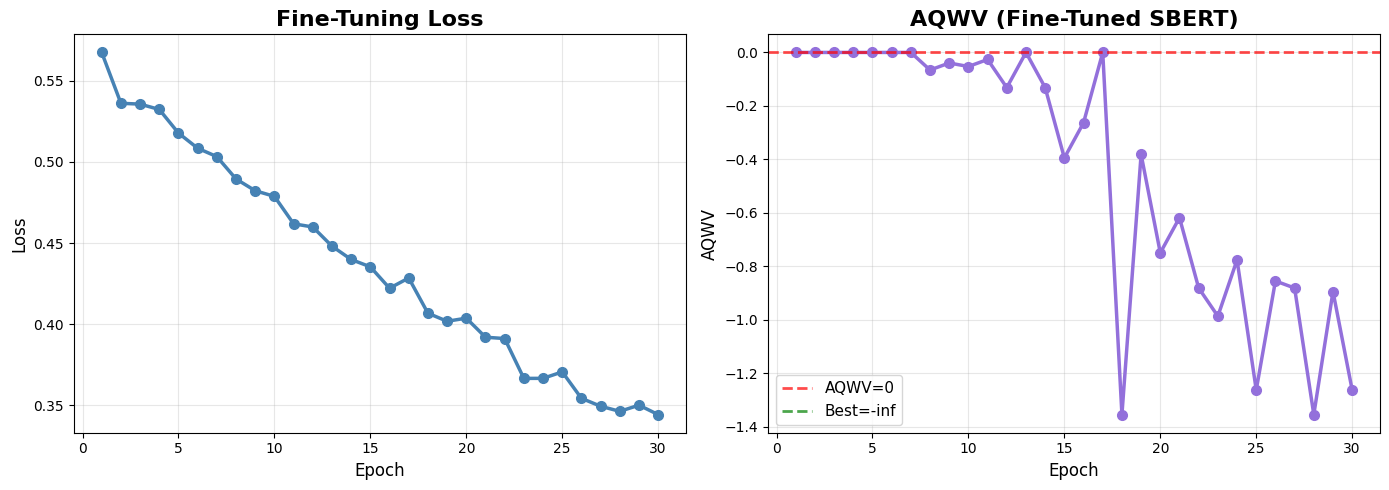


Fine-Tuning Complete!
Best AQWV (SBERT): -inf


In [ ]:
import matplotlib.pyplot as plt

ft_criterion = nn.BCEWithLogitsLoss()
ft_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, sbert_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

ft_train_losses = []
ft_aqwv_scores = []
ft_epochs_list = []

ft_best_aqwv = -float('inf')
ft_patience = 5
ft_patience_counter = 0

for epoch in range(30):
    sbert_model.train()
    total_loss = 0
    for queries, docs, labels in tqdm(ft_train_loader, desc=f"FT Epoch {epoch+1}"):
        labels = labels.to(device)
        ft_optimizer.zero_grad()
        output = sbert_model(queries, docs)
        loss = ft_criterion(output.squeeze(), labels)
        loss.backward()
        ft_optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(ft_train_loader)
    aqwv = compute_aqwv_sbert(sbert_model, ft_test_loader, threshold=0.5)

    ft_train_losses.append(avg_loss)
    ft_aqwv_scores.append(aqwv)
    ft_epochs_list.append(epoch + 1)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, AQWV: {aqwv:.4f}")

    # if aqwv > ft_best_aqwv:
    #     ft_best_aqwv = aqwv
    #     ft_patience_counter = 0
    #     torch.save(sbert_model.state_dict(), 'best_sbert_model.pt')
    # else:
    #     ft_patience_counter += 1
    #     if ft_patience_counter >= ft_patience:
    #         print(f"Early stopping at epoch {epoch+1}, Best AQWV: {ft_best_aqwv:.4f}")
    #         sbert_model.load_state_dict(torch.load('best_sbert_model.pt'))
    #         break

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ft_epochs_list, ft_train_losses, color='steelblue', marker='o', linewidth=2.5, markersize=7)
ax1.set_title('Fine-Tuning Loss', fontsize=16, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(ft_epochs_list, ft_aqwv_scores, color='mediumpurple', marker='o', linewidth=2.5, markersize=7)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='AQWV=0')
ax2.axhline(y=ft_best_aqwv, color='green', linestyle='--', alpha=0.7, linewidth=2,
            label=f'Best={ft_best_aqwv:.4f}')
ax2.set_title('AQWV (Fine-Tuned SBERT)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('AQWV', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Fine-Tuning Complete!")
print(f"Best AQWV (SBERT): {ft_best_aqwv:.4f}")
print(f"{'='*50}")

### Выводы

* **CNN SEARCHER** не может выучить cross-lingual alignment из нуля на маленьком синтетическом датасете -- shared vocabulary не является эквивалентом cross-lingual embedding
* **Fine-Tuned SBERT** использует веса, предобученные на ~ 50 языках, и должен уметь сопоставлять финские и английские предложения в одном пространстве.

Файнтьюним только MLP-голову (~1K параметров)

* Результат SBERT лучше, но всё равно ниже нуля и быстно переобучается.